In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB
None


Сразу переведем столбец "Дата" в правильный формат

In [10]:
df['Дата'] = pd.to_datetime(df['Дата'])

Сгруппируйте данные по дате, посчитайте количество продаж

In [11]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [12]:
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Нарисуйте график продаж у `grouped_df`

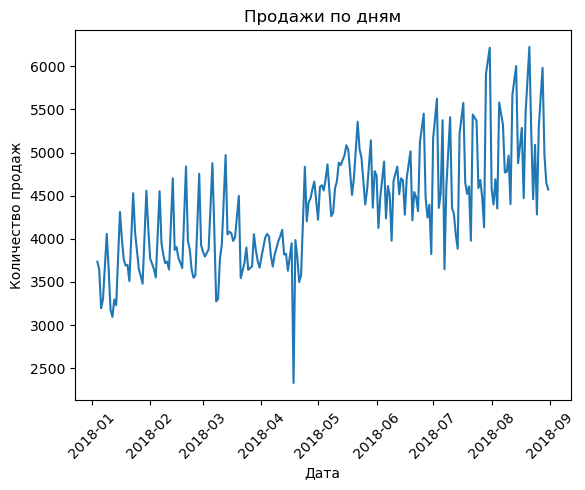

In [13]:
plt.figure()
plt.plot(grouped_df['Дата'], grouped_df['Количество'])
plt.title('Продажи по дням')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.xticks(rotation=45)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
#На графике наблюдается общий восходящий тренд продаж за весь рассматриваемый период.
Несмотря на это, динамика не является равномерной: в марте–апреле 2018 года фиксируется снижение показателей, включая резкое падение в середине апреля.
Однако начиная с мая 2018 года продажи снова демонстрируют стабильный рост и продолжают увеличиваться до конца периода.
Таким образом, несмотря на временную просадку в середине периода, общий тренд остаётся положительным.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [14]:
outlier = df.loc[df['Количество'].idxmax()]
print(outlier)

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [15]:
# день недели (среда = 2)
df['weekday'] = df['Дата'].dt.weekday

filtered = df[
    (df['weekday'] == 2) &
    (df['Дата'].dt.month.isin([6, 7, 8]))
]

top_products = (
    filtered.groupby(['Склад', 'Номенклатура'])['Количество']
    .sum()
    .reset_index()
)

top_products = top_products.sort_values(['Склад', 'Количество'], ascending=[True, False])

top_per_warehouse = top_products.groupby('Склад').head(1)

print(top_per_warehouse)

    Склад Номенклатура  Количество
1       1    product_1        2981
24      2    product_1        2887
46      3    product_1        2267
69      4    product_1        2385
92      5    product_1        1956


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [22]:
weather = pd.read_csv('weather.csv')

# оставляем нужные столбцы 
weather = weather[['Дата', 'T']]

weather['Дата'] = pd.to_datetime(weather['Дата'])

In [25]:
merged = pd.merge(grouped_df, weather_daily, on='Дата', how='left')

print(merged.head())

        Дата  Количество        T
0 2018-01-04        3734 -13.0875
1 2018-01-05        3643 -17.2500
2 2018-01-06        3193 -14.1250
3 2018-01-07        3298 -12.3375
4 2018-01-09        4055  -7.3875


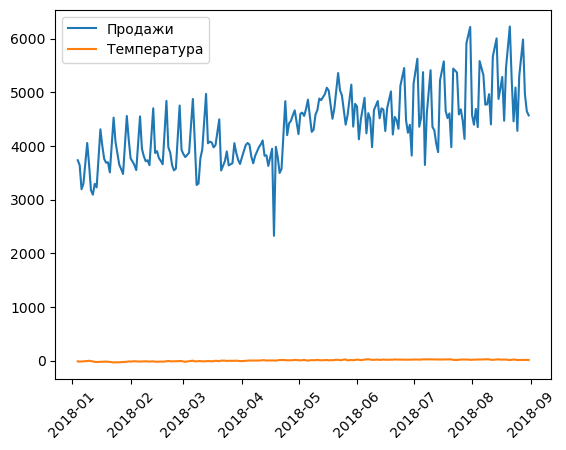

In [26]:
plt.figure()
plt.plot(merged['Дата'], merged['Количество'], label='Продажи')
plt.plot(merged['Дата'], merged['T'], label='Температура')
plt.legend()
plt.xticks(rotation=45)
plt.show()